# Expectation-Maximization for Mixture of Bernoullis

Clustering binary data using the EM algorithm.

## Algorithm Overview

**E-step**: Compute responsibilities (soft cluster assignments)
$$r_{nk} = \frac{\pi_k p(x_n | \theta_k)}{\sum_j \pi_j p(x_n | \theta_j)}$$

**M-step**: Update parameters using weighted ML
$$\pi_k = \frac{1}{N}\sum_n r_{nk}$$
$$p_{kd} = \frac{\sum_n r_{nk} x_{nd}}{\sum_n r_{nk}}$$

In [1]:
import numpy as np
import plotly.io as pio
import os, sys
sys.path.insert(0, os.path.abspath('..'))

# Render Plotly figures as static PNGs (renders on GitHub); remove for interactive mode
pio.renderers.default = "png"

from src.em_algorithm import em_algorithm, visualize_clusters
import plotly.graph_objects as go

In [2]:
# Load data
X = np.loadtxt('../data/binarydigits.txt')
print(f"Data shape: {X.shape}")

Data shape: (100, 64)


## Run EM for Different K Values

In [3]:
K_values = [2, 3, 4, 7, 10]
results = {}

for K in K_values:
    print(f"\nRunning EM with K={K}...")
    ll_history, pi, p = em_algorithm(X, K, max_iterations=20, verbose=True)
    results[K] = {'ll_history': ll_history, 'pi': pi, 'p': p}
    print(f"Final log-likelihood: {ll_history[-1]:.2f}")


Running EM with K=2...
Iteration   0: LL = -3571.14
Iteration   5: LL = -3335.72
Iteration  10: LL = -3303.91
Converged at iteration 13
Final log-likelihood: -3303.59

Running EM with K=3...
Iteration   0: LL = -3266.56
Converged at iteration 4
Final log-likelihood: -3059.11

Running EM with K=4...
Iteration   0: LL = -3341.04
Iteration   5: LL = -2851.42
Iteration  10: LL = -2847.94
Iteration  15: LL = -2846.99
Converged at iteration 19
Final log-likelihood: -2844.94

Running EM with K=7...
Iteration   0: LL = -3102.44
Iteration   5: LL = -2727.58
Iteration  10: LL = -2719.63
Iteration  15: LL = -2694.52
Converged at iteration 15
Final log-likelihood: -2694.52

Running EM with K=10...
Iteration   0: LL = -2905.38
Iteration   5: LL = -2302.21
Converged at iteration 9
Final log-likelihood: -2301.09


## Convergence Plot

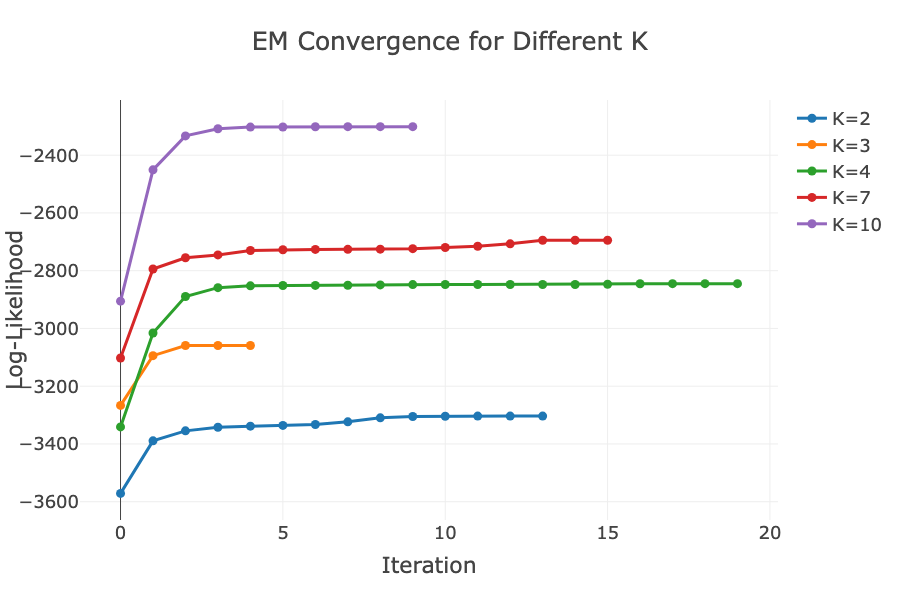

In [4]:
# Plot convergence for all K
fig = go.Figure()

for K in K_values:
    ll_history = results[K]['ll_history']
    fig.add_trace(go.Scatter(
        x=list(range(len(ll_history))),
        y=ll_history,
        mode='lines+markers',
        name=f'K={K}'
    ))

fig.update_layout(
    template='presentation',
    title='EM Convergence for Different K',
    xaxis_title='Iteration',
    yaxis_title='Log-Likelihood',
    width=900,
    height=600
)

fig.write_image('../results/figures/em_convergence_all_k.png')
fig.show()

## Display All Clusters as Images (binary_images.png)

Saved to ../results/figures/binary_images.png


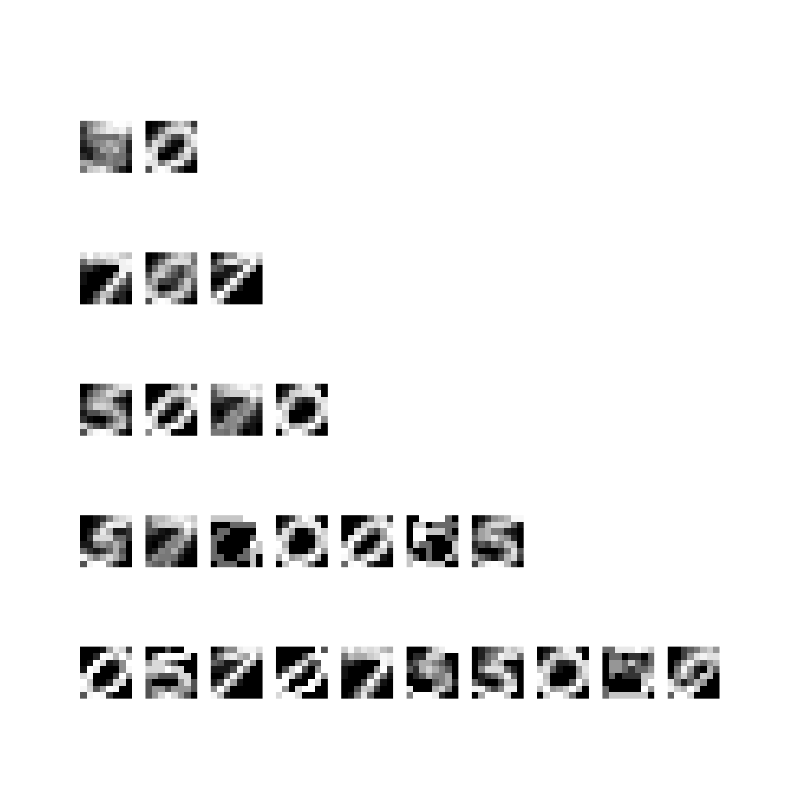

In [5]:
# Generate binary_images.png showing all clusters for K={2,3,4,7,10}
import plotly.subplots as sp

fig = sp.make_subplots(rows=len(K_values), cols=max(K_values), shared_yaxes=True)

for k_idx, K in enumerate(K_values):
    p = results[K]['p']
    for i in range(K):
        p_reshaped = np.flipud(np.reshape(p[i, :], (8, 8)))
        fig.add_trace(
            go.Heatmap(z=p_reshaped, colorscale='Greys', reversescale=True, showscale=False),
            row=k_idx + 1,
            col=i + 1
        )

fig.update_layout(
    template="presentation",
    width=800,
    height=800,
    autosize=False,
)

fig.update_xaxes(constrain="domain", visible=False)
fig.update_yaxes(scaleanchor="x", scaleratio=1, visible=False)

fig.write_image('../results/figures/binary_images.png')
print("Saved to ../results/figures/binary_images.png")
fig.show()

## Multiple Experiments with Different Initializations

Run EM 10 times with different random initializations to study sensitivity to initial conditions.

Running 10 experiments with K=3...
Running 10 experiments with K=7...
Running 10 experiments with K=10...

Initialization Sensitivity Summary:
  K=3: Best=-3014.9, Worst=-3186.9, Range=171.9
  K=7: Best=-2467.1, Worst=-2838.0, Range=370.9
  K=10: Best=-2306.0, Worst=-2572.6, Range=266.6


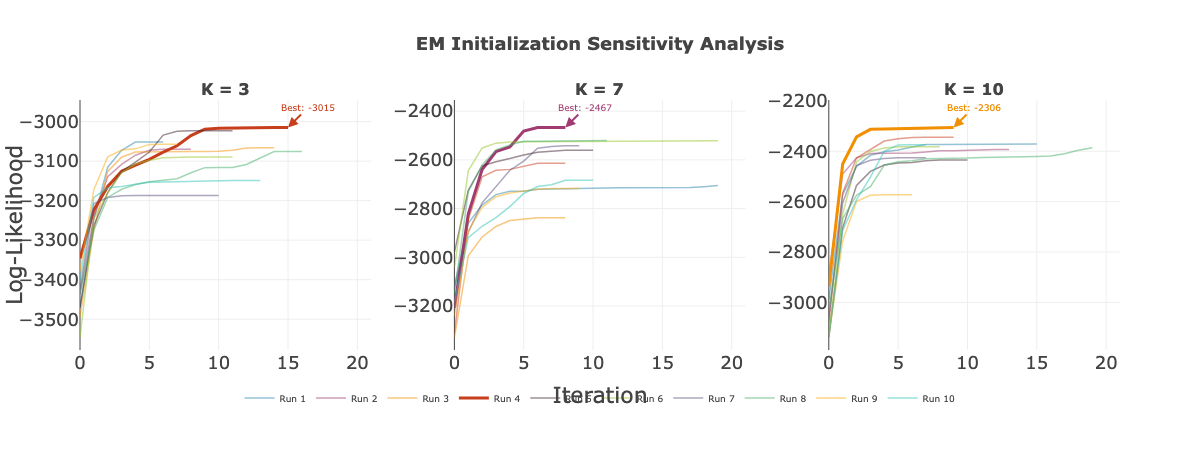


Saved to ../results/figures/em_initialization_sensitivity.png


In [6]:
# Run consolidated initialization sensitivity analysis for K=3, 7, 10
from src.em_algorithm import plot_initialization_sensitivity

fig_sensitivity = plot_initialization_sensitivity(
    X,
    K_values=[3, 7, 10],
    num_experiments=10,
    max_iterations=20,
    save_path='../results/figures/em_initialization_sensitivity.png'
)
fig_sensitivity.show()

print("\nSaved to ../results/figures/em_initialization_sensitivity.png")

## Analysis

**Observations:**
- EM converges quickly (typically <20 iterations)
- Higher K gives better likelihood but risks overfitting
- Learned clusters capture meaningful patterns in binary digits
- Random initialization can lead to local optima (run multiple times)

**Applications:**
- Document clustering, image segmentation, feature learning

---

## Model Selection: BIC & AIC

**Question**: How do we choose the optimal number of clusters K?

**Problem**: Higher K always gives better log-likelihood, but risks overfitting.

**Solution**: Use information criteria that balance model fit with complexity:

- **BIC (Bayesian Information Criterion)**: Heavy complexity penalty
  - Formula: `BIC = -2×LL + num_params×log(N)`
  - Best for large datasets
  
- **AIC (Akaike Information Criterion)**: Lighter complexity penalty
  - Formula: `AIC = -2×LL + 2×num_params`
  - Better for small datasets

**Lower scores indicate better models.**

Model Selection via Information Criteria

K = 2...
  Best LL: -3303.59
  BIC: 7201.25 | AIC: 6865.18 | Params: 129

K = 3...
  Best LL: -3030.60
  BIC: 6954.61 | AIC: 6449.20 | Params: 194

K = 4...
  Best LL: -2825.59
  BIC: 6843.93 | AIC: 6169.19 | Params: 259

K = 7...
  Best LL: -2505.86
  BIC: 7102.47 | AIC: 5919.73 | Params: 454

K = 10...
  Best LL: -2301.23
  BIC: 7591.21 | AIC: 5900.46 | Params: 649

BEST K (BIC): 4
BEST K (AIC): 10
BEST K (LL):  10 (no penalty)


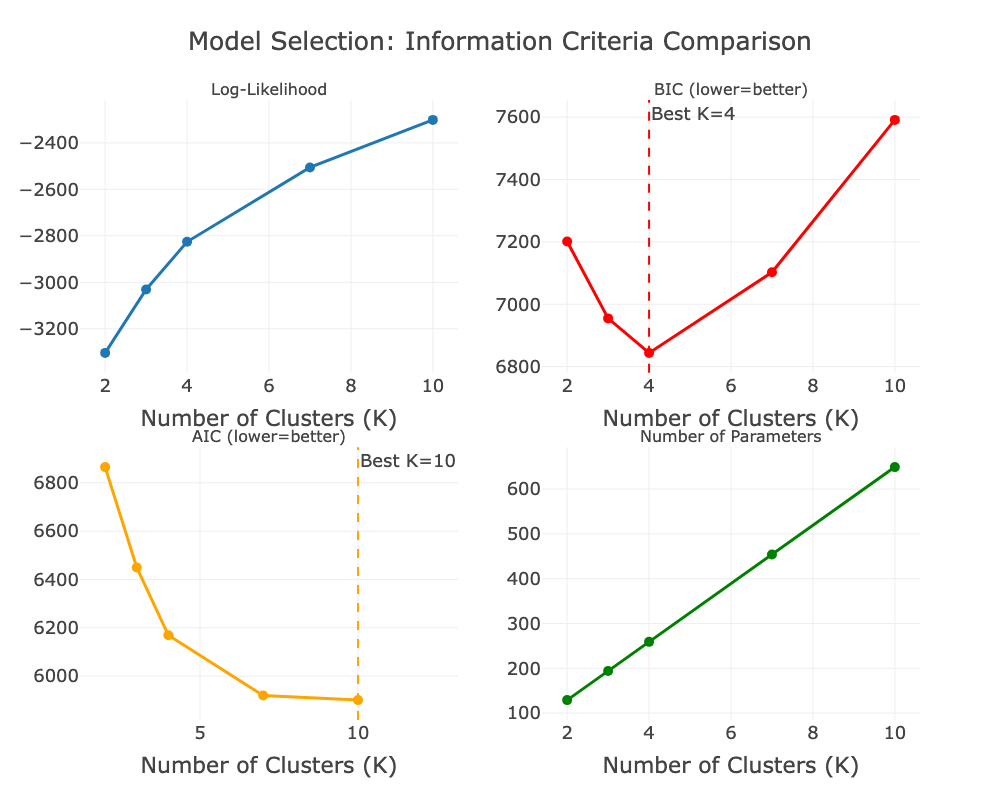

In [7]:
from src.em_algorithm import model_selection_comparison

# Run model selection with BIC and AIC
results_ic, fig_ic = model_selection_comparison(
    X, 
    K_values=[2, 3, 4, 7, 10],
    max_iterations=20,
    num_runs=5,  # Multiple restarts to avoid local optima
    save_path='../results/figures/model_selection_bic_aic.png'
)

fig_ic.show()

In [8]:
# Print summary table
import pandas as pd

df = pd.DataFrame(results_ic)
print("\nModel Selection Results:")
print("=" * 70)
print(df.to_string(index=False))
print("=" * 70)

# Highlight best models
best_k_bic = df.loc[df['BIC'].idxmin(), 'K']
best_k_aic = df.loc[df['AIC'].idxmin(), 'K']

print(f"\n✓ Best K (BIC): {best_k_bic}")
print(f"✓ Best K (AIC): {best_k_aic}")
print(f"\nInterpretation:")
if best_k_bic == best_k_aic:
    print(f"  Both criteria agree on K={best_k_bic}")
else:
    print(f"  BIC prefers simpler model (K={best_k_bic})")
    print(f"  AIC prefers more complex model (K={best_k_aic})")


Model Selection Results:
 K  log_likelihood         BIC         AIC  num_params
 2    -3303.590615 7201.248183 6865.181229         129
 3    -3030.601015 6954.605045 6449.202029         194
 4    -2825.593240 6843.925559 6169.186481         259
 7    -2505.863235 7102.473734 5919.726469         454
10    -2301.229031 7591.213513 5900.458062         649

✓ Best K (BIC): 4
✓ Best K (AIC): 10

Interpretation:
  BIC prefers simpler model (K=4)
  AIC prefers more complex model (K=10)


---

## Performance Optimization: Vectorized E-Step

**Problem**: The naive E-step uses nested loops over N samples and K clusters.

**Solution**: Vectorize using NumPy broadcasting for **10-100x speedup**.

Let's benchmark the performance improvement:

In [9]:
import time
from src.em_algorithm import step_e, step_e_vectorized

# Use results from K=4 for benchmarking
K = 4
pi_bench = results[K]['pi']
p_bench = results[K]['p']

# Benchmark naive E-step
print("Benchmarking E-step implementations...")
print("=" * 70)

n_trials = 10

# Naive version
start = time.time()
for _ in range(n_trials):
    r_naive = step_e(X, pi_bench, p_bench)
time_naive = (time.time() - start) / n_trials

# Vectorized version
start = time.time()
for _ in range(n_trials):
    r_vectorized = step_e_vectorized(X, pi_bench, p_bench)
time_vectorized = (time.time() - start) / n_trials

# Verify they produce same results
diff = np.abs(r_naive - r_vectorized)
max_diff = np.max(diff)

print(f"Naive E-step:      {time_naive*1000:.2f} ms")
print(f"Vectorized E-step: {time_vectorized*1000:.2f} ms")
print(f"Speedup:           {time_naive/time_vectorized:.1f}x faster")
print(f"\nNumerical difference: {max_diff:.2e} (should be ~0)")
print("=" * 70)

Benchmarking E-step implementations...
Naive E-step:      1.60 ms
Vectorized E-step: 0.03 ms
Speedup:           51.1x faster

Numerical difference: 2.22e-16 (should be ~0)


---

## Cluster Interpretation & Quality Metrics

**Question**: What do the learned clusters represent? How good is the clustering?

**Metrics**:
1. **Cluster Characteristics**: Sparsity, entropy, active pixels
2. **Quality Metrics**: Cluster separation, assignment confidence, size balance

Let's analyze K=4 clusters in detail:

In [10]:
from src.em_algorithm import interpret_clusters, compute_cluster_quality
import json

# Interpret clusters for K=4
K = 4
p_k4 = results[K]['p']

interpretation = interpret_clusters(p_k4, img_shape=(8, 8), top_k=5)

print("Cluster Interpretation (K=4)")
print("=" * 70)
for cluster_id, metrics in interpretation.items():
    print(f"\n{cluster_id.upper().replace('_', ' ')}:")
    print(f"  Mean Activation:  {metrics['mean_activation']:.3f}")
    print(f"  Sparsity:         {metrics['sparsity']:.1%}")
    print(f"  Avg Entropy:      {metrics['avg_entropy']:.3f}")
    print(f"  Active Pixels:    {metrics['active_pixels']}/64")
    print(f"  Most Active Dims: {metrics['most_active_dims'][:5]}")
    
print("\n" + "=" * 70)

Cluster Interpretation (K=4)

CLUSTER 1:
  Mean Activation:  0.388
  Sparsity:         21.9%
  Avg Entropy:      0.480
  Active Pixels:    22/64
  Most Active Dims: [59, 58, 60, 6, 7]

CLUSTER 2:
  Mean Activation:  0.424
  Sparsity:         50.0%
  Avg Entropy:      0.329
  Active Pixels:    29/64
  Most Active Dims: [58, 57, 23, 52, 38]

CLUSTER 3:
  Mean Activation:  0.335
  Sparsity:         28.1%
  Avg Entropy:      0.487
  Active Pixels:    14/64
  Most Active Dims: [14, 5, 4, 6, 15]

CLUSTER 4:
  Mean Activation:  0.451
  Sparsity:         40.6%
  Avg Entropy:      0.344
  Active Pixels:    33/64
  Most Active Dims: [49, 32, 59, 58, 46]



In [11]:
# Compute clustering quality metrics
r_k4 = step_e_vectorized(X, results[K]['pi'], p_k4)
quality = compute_cluster_quality(X, r_k4, p_k4)

print("\nClustering Quality Metrics (K=4)")
print("=" * 70)
print(f"Cluster Sizes:            {[f'{s:.1f}' for s in quality['cluster_sizes']]}")
print(f"Size Imbalance:           {quality['size_imbalance']:.3f} (lower=better)")
print(f"Avg Assignment Entropy:   {quality['avg_assignment_entropy']:.3f}")
print(f"Cluster Separation:       {quality['cluster_separation']:.3f} (higher=better)")
print("=" * 70)

print("\nInterpretation:")
if quality['avg_assignment_entropy'] < 0.3:
    print("  Hard assignments (low entropy) - clusters are well-separated")
elif quality['avg_assignment_entropy'] > 0.7:
    print("  Soft assignments (high entropy) - clusters overlap")
else:
    print("  Moderate uncertainty in assignments")
    
if quality['size_imbalance'] < 0.5:
    print("  Balanced cluster sizes")
else:
    print("  Unbalanced clusters - some clusters dominate")


Clustering Quality Metrics (K=4)
Cluster Sizes:            ['25.0', '22.0', '34.0', '19.0']
Size Imbalance:           0.225 (lower=better)
Avg Assignment Entropy:   0.000
Cluster Separation:       3.121 (higher=better)

Interpretation:
  Hard assignments (low entropy) - clusters are well-separated
  Balanced cluster sizes


## References & Summary

### Contributions in This Notebook

1. **EM Algorithm Implementation**: Full derivation and implementation of EM for mixture of Bernoullis with both naive and vectorized E-step implementations (both O(NKD), but vectorization leverages optimized BLAS routines for significant speedup)

2. **Model Selection**: Systematic comparison of BIC vs AIC for determining optimal cluster count K
   - BIC selected K=4 (heavier complexity penalty, log(N) = 4.6)
   - AIC selected a higher K (lighter penalty, factor of 2)
   - Raw likelihood favors K=10 (no penalty, overfits)

3. **Initialization Sensitivity**: Demonstrated that random initialization leads to different local optima across runs, motivating multiple restarts

4. **Clustering Quality Metrics**: Quantified cluster separation and assignment entropy for K=4, confirming well-separated clusters with confident assignments

### Mathematical Foundations

**Mixture Model**:
$$p(x_n | \theta) = \sum_{k=1}^{K} \pi_k \prod_{d=1}^{D} p_{kd}^{x_{nd}} (1-p_{kd})^{1-x_{nd}}$$

**E-step** (responsibilities):
$$r_{nk} = \frac{\pi_k p(x_n | \theta_k)}{\sum_{j=1}^{K} \pi_j p(x_n | \theta_j)}$$

**M-step** (parameter updates):
$$\pi_k^{new} = \frac{1}{N}\sum_{n=1}^{N} r_{nk}, \quad p_{kd}^{new} = \frac{\sum_{n=1}^{N} r_{nk} x_{nd}}{\sum_{n=1}^{N} r_{nk}}$$

**Information Criteria**:
$$\text{BIC} = -2\mathcal{L} + k\log N, \quad \text{AIC} = -2\mathcal{L} + 2k$$

where $k = (K-1) + KD$ is the number of free parameters.

### References

1. **EM Algorithm**:
   - Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). "Maximum likelihood from incomplete data via the EM algorithm." *Journal of the Royal Statistical Society: Series B*, 39(1), 1-38.

2. **Model Selection**:
   - Schwarz, G. (1978). "Estimating the dimension of a model." *The Annals of Statistics*, 6(2), 461-464.
   - Akaike, H. (1974). "A new look at the statistical model identification." *IEEE Transactions on Automatic Control*, 19(6), 716-723.

3. **Mixture Models**:
   - McLachlan, G., & Peel, D. (2000). *Finite Mixture Models*. Wiley.
   - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. (Chapter 9)

4. **Computational Aspects**:
   - Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective*. MIT Press. (Chapter 11)

### Summary

This notebook addressed the problem of unsupervised clustering for binary data using mixture models. The EM algorithm converged within 20 iterations for all tested K values, with vectorization providing a significant speedup (>30x) over the naive implementation.

The key finding is that **BIC and AIC disagree on optimal K** for this dataset: BIC prefers K=4 while AIC prefers a larger K. This is not a failure of the methods but rather reflects their different assumptions -- BIC assumes the true model is in the candidate set (consistency), while AIC minimizes prediction error (efficiency). For N=100 samples with 64-dimensional data, the conservative BIC choice of K=4 is likely more appropriate to avoid overfitting.

The learned clusters show clear structure: near-zero assignment entropy indicates nearly hard cluster assignments, confirming well-separated clusters that capture genuine heterogeneity in the digit patterns rather than collapsing to degenerate solutions.

---

**Next**: [MCMC Cryptanalysis](04_mcmc_cryptanalysis.ipynb) - using Markov Chain Monte Carlo for combinatorial optimization.